In [52]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

deck = 52
no_of_red_cards = deck//2
no_of_black_cards = deck - no_of_red_cards

no_of_black_cards, no_of_red_cards

(26, 26)

In [53]:
def experiment(n_samples : int):

    records = []
    for _ in tqdm(range(n_samples)):
        cards = np.random.choice(['R','B'],size=deck//2)
        number_of_red_cards = (cards=='R').sum()
        records.append([number_of_red_cards, deck - number_of_red_cards])
    return np.array(records)
    
    
color_count_records = experiment(10**5)
    

100%|██████████| 100000/100000 [00:01<00:00, 99733.09it/s]


In [56]:
## Let’s create a table that keeps track of how many of our games result in a certain number of red cards draw.

redCardsCounter = Counter(color_count_records[:,0])

no_of_red_cards_drawn = np.arange(0,27)
no_of_times_happened = np.vectorize(lambda x: redCardsCounter[x])(no_of_red_cards_drawn)

exp_results = pd.DataFrame({"red_cards_drawn": no_of_red_cards_drawn,
                            "no_of_occurance": no_of_times_happened})


exp_results['percentage'] = round((exp_results['no_of_occurance'] / exp_results['no_of_occurance'].max())*100,3)
exp_results

,red_cards_drawn,no_of_occurance,percentage
0,0,0,0.000
1,1,0,0.000
2,2,1,0.006
3,3,5,0.032
4,4,22,0.143
5,5,108,0.700
6,6,321,2.080
7,7,1035,6.708
8,8,2287,14.823
9,9,4491,29.108


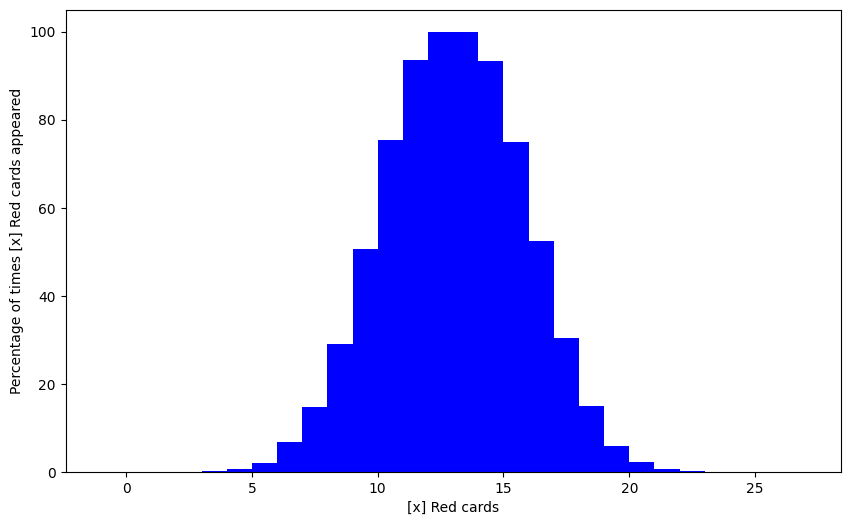

In [57]:
plt.figure(figsize=(10,6))
plt.bar(exp_results['red_cards_drawn'], exp_results['percentage'], width=2,facecolor="blue")
plt.xlabel("[x] Red cards")
plt.ylabel("Percentage of times [x] Red cards appeared")
plt.show()

In [ ]:
## So if someone asks What is the estimated chance of drawing 7 red cards?

## Answer : There is a 6.7% chance of drawing 7 red cards.